In [3]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from typing import Dict, List, Tuple, Optional, Union
from dataclasses import dataclass
import bisect
from collections import defaultdict

# PyTorch and PyTorch Geometric
import torch
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader as TorchDataLoader
from torch_geometric.nn import GCNConv, BatchNorm, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Batch

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Utilities
import pickle
from tqdm import tqdm
import logging
import time
from pathlib import Path

# Visualization
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

warnings.filterwarnings('ignore')

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("training_improved.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

## Configuration and Constants


In [4]:
@dataclass
class ModelConfig:
    """Configuration for the improved GNN model"""
    # Model architecture
    hidden_dim: int = 128
    num_layers: int = 4
    dropout: float = 0.2
    attention_heads: int = 4
    
    # Training
    learning_rate: float = 0.001
    batch_size: int = 64
    num_epochs: int = 10
    patience: int = 8
    min_delta: float = 1e-4
    
    # Target transformation
    use_log_latency: bool = True
    use_classification: bool = False
    num_latency_buckets: int = 5
    multi_task: bool = False  # Predict latency + energy
    
    # Data processing
    normalize_features: bool = True
    max_graph_size: int = 50  # Limit graph size for memory
    
config = ModelConfig()

# Platform type mappings for robust encoding
PLATFORM_TYPES = ['rpiCpu', 'xavierCpu', 'xavierGpu', 'xavierDla', 'pynqFpga']
TASK_TYPES = ['dnn1', 'dnn2']  # Will be updated based on data
HARDWARE_TYPES = ['cpu', 'gpu', 'dla', 'fpga']

## Enhanced Data Loading and Processing


In [5]:
def load_results(results_folder):
    """Load simulation results from JSON files"""
    result_files = [f for f in os.listdir(results_folder) if f.endswith('.json')]
    results = {}
    
    for file in result_files:
        file_path = os.path.join(results_folder, file)
        with open(file_path, 'r') as f:
            results[file] = json.load(f)
    
    return results

def create_network_latency_lookup(latency_df: pd.DataFrame) -> Dict[Tuple[str, str], float]:
    """Create efficient lookup for network latency between node pairs"""
    lookup = {}
    
    for _, row in latency_df.iterrows():
        key = (row['source_node'], row['execution_node'])
        # Use the network latency value, defaulting to 0.1 for local communications
        latency = 0.1 if row['local_communications'] else row['network_latency']
        lookup[key] = latency
    
    return lookup


In [6]:
def extract_network_latency_matrix(results_data, experiment_name):
    """Extract network latency information from task results"""
    latency_data = []
    
    for result_file, result in results_data.items():
        if 'taskResults' in result['stats']:
            for task in result['stats']['taskResults']:
                latency_info = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'source_node': task['sourceNode'],
                    'execution_node': task['executionNode'],
                    'network_latency': task['networkLatency'],
                    'local_communications': task['localCommunications']
                }
                latency_data.append(latency_info)
    
    return pd.DataFrame(latency_data)


In [7]:
def extract_enhanced_node_metrics(results, experiment_name):
    """Extract enhanced node metrics with better feature engineering"""
    node_data = []
    platform_data = []
    storage_data = []

    for result_file, result in results.items():
        if 'nodeResults' in result['stats']:
            for node in result['stats']['nodeResults']:
                # Convert numeric node_id to string format to match task data
                node_id = f"node{node['nodeId']}"
                
                # Basic node metrics
                node_metrics = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'node_id': node_id,  # Now using string format
                    'unused': node['unused'],
                    'scheduling_time': node['schedulingTime'],
                    'storage_time': node['storageTime'],
                    'local_dependencies': node['localDependencies'],
                    'cache_hits': node['cacheHits'],
                }

                # Energy metrics by platform type
                total_energy = 0
                total_idle_energy = 0
                total_idle_time = 0
                
                if 'energy' in node:
                    for platform_type, energy in node['energy'].items():
                        node_metrics[f'energy_{platform_type}'] = energy
                        total_energy += energy

                if 'energyIdle' in node:
                    for platform_type, energy in node['energyIdle'].items():
                        node_metrics[f'idle_energy_{platform_type}'] = energy
                        total_idle_energy += energy

                if 'idleTime' in node:
                    for platform_type, time_val in node['idleTime'].items():
                        node_metrics[f'idle_time_{platform_type}'] = time_val
                        total_idle_time += time_val

                # Aggregate metrics
                node_metrics.update({
                    'total_energy': total_energy,
                    'total_idle_energy': total_idle_energy,
                    'total_idle_time': total_idle_time,
                    'energy_efficiency': total_energy / max(total_idle_time, 1),
                    'cache_hit_rate': node_metrics['cache_hits'] / max(node_metrics['local_dependencies'], 1)
                })

                node_data.append(node_metrics)

                # Enhanced platform metrics
                if 'platformResults' in node:
                    for platform in node['platformResults']:
                        platform_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node_id,  # Now using string format
                            'platform_id': platform['platformId'],
                            'platform_type': platform['platformType']['shortName'],
                            'platform_hardware': platform['platformType']['hardware'],
                            'platform_price': platform['platformType']['price'],
                            'energy': platform['energy'],
                            'energy_idle': platform['energyIdle'],
                            'idle_time': platform['idleTime'],
                            'idle_proportion': platform['idleProportion'],
                            'storage_time': platform['storageTime']
                        }
                        
                        # Calculate derived metrics
                        active_time = platform_metrics['idle_time'] / max(platform_metrics['idle_proportion'], 0.001)
                        platform_metrics.update({
                            'active_time': active_time,
                            'utilization': 1 - platform_metrics['idle_proportion'],
                            'energy_per_active_time': platform_metrics['energy'] / max(active_time, 1),
                            'performance_per_dollar': active_time / max(platform_metrics['platform_price'], 1)
                        })
                        
                        platform_data.append(platform_metrics)

                # Storage metrics (unchanged)
                if 'storageResults' in node:
                    for storage in node['storageResults']:
                        storage_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node_id,  # Now using string format
                            'storage_id': storage['storageId'],
                            'has_usage_data': len(storage['totalUsage']) > 0
                        }
                        storage_data.append(storage_metrics)

    return pd.DataFrame(node_data), pd.DataFrame(platform_data), pd.DataFrame(storage_data)


In [8]:
def extract_enhanced_task_metrics(results, experiment_name):
    """Extract enhanced task metrics with additional features"""
    tasks_data = []

    for result_file, result in results.items():
        if 'taskResults' in result['stats']:
            for task in result['stats']['taskResults']:
                task_data = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'task_id': task['taskId'],
                    'dispatched_time': task['dispatchedTime'],
                    'scheduled_time': task['scheduledTime'],
                    'arrived_time': task['arrivedTime'],
                    'started_time': task['startedTime'],
                    'done_time': task['doneTime'],
                    'task_type': task['taskType']['name'],
                    'platform_type': task['platform']['shortName'],
                    'platform_hardware': task['platform']['hardware'],
                    'elapsed_time': task['elapsedTime'],
                    'pull_time': task['pullTime'],
                    'cold_start_time': task['coldStartTime'],
                    'execution_time': task['executionTime'],
                    'wait_time': task['waitTime'],
                    'queue_time': task['queueTime'],
                    'initialization_time': task['initializationTime'],
                    'compute_time': task['computeTime'],
                    'communications_time': task['communicationsTime'],
                    'cold_started': task['coldStarted'],
                    'cache_hit': task['cacheHit'],  
                    'local_dependencies': task['localDependencies'],
                    'local_communications': task['localCommunications'],
                    'energy': task['energy'],
                    'network_latency': task['networkLatency'],
                    'source_node': task['sourceNode'],
                    'execution_node': task['executionNode'],
                    'execution_platform': task['executionPlatform'],
                }

                # Calculate task latency components
                task_data['scheduling_latency'] = task_data['scheduled_time'] - task_data['dispatched_time']
                task_data['arrival_latency'] = task_data['arrived_time'] - task_data['scheduled_time']
                task_data['start_latency'] = task_data['started_time'] - task_data['arrived_time']
                task_data['processing_latency'] = task_data['done_time'] - task_data['started_time']
                task_data['end_to_end_latency'] = task_data['done_time'] - task_data['dispatched_time']
                
                # Additional derived features
                task_data.update({
                    'task_complexity': task_data['compute_time'] + task_data['communications_time'],
                    'overhead_ratio': (task_data['end_to_end_latency'] - task_data['execution_time']) / max(task_data['execution_time'], 1),
                    'communication_ratio': task_data['communications_time'] / max(task_data['compute_time'], 1),
                    'cold_start_penalty': task_data['cold_start_time'] / max(task_data['execution_time'], 1)
                })

                tasks_data.append(task_data)

    return pd.DataFrame(tasks_data)


In [9]:
def load_experiment_data(experiments, cache_dir="src/notebooks/improved_data_cache"):
    """Load experiment data with enhanced features"""
    os.makedirs(cache_dir, exist_ok=True)
    experiment_data = {}

    for name, folder in experiments.items():
        cache_path = os.path.join(cache_dir, f"{name}_enhanced_data.pkl")
        if os.path.exists(cache_path):
            logger.info(f"Loading cached data for {name}")
            with open(cache_path, "rb") as f:
                experiment_data[name] = pickle.load(f)
        else:
            logger.info(f"Processing data for {name}")
            results = load_results(folder)
            node_df, platform_df, storage_df = extract_enhanced_node_metrics(results, name)
            task_df = extract_enhanced_task_metrics(results, name)
            latency_df = extract_network_latency_matrix(results, name)
            
            experiment_data[name] = {
                "node_df": node_df,
                "platform_df": platform_df,
                "storage_df": storage_df,
                "task_df": task_df,
                "latency_df": latency_df
            }
            
            logger.info(f"Caching data for {name}")
            with open(cache_path, "wb") as f:
                pickle.dump(experiment_data[name], f)
                
    return experiment_data

## Enhanced Feature Engineering and Normalization


In [10]:
class FeatureEngineer:
    """Enhanced feature engineering with normalization and robust encoding"""
    
    def __init__(self):
        self.scalers = {}
        self.encoders = {}
        self.fitted = False
        
    def fit(self, task_df, platform_df, node_df):
        """Fit scalers and encoders on the data"""
        logger.info("Fitting feature scalers and encoders")
        
        # Fit scalers for numerical features
        numerical_features = [
            'platform_price', 'energy', 'energy_idle', 'idle_time', 'idle_proportion',
            'scheduling_time', 'storage_time', 'local_dependencies', 'cache_hits',
            'dispatched_time', 'task_complexity', 'overhead_ratio', 'communication_ratio',
            'cold_start_penalty', 'network_latency', 'utilization', 'energy_per_active_time',
            'performance_per_dollar'
        ]
        
        for feature in numerical_features:
            if feature in platform_df.columns:
                scaler = RobustScaler()  # More robust to outliers
                scaler.fit(platform_df[feature].values.reshape(-1, 1))
                self.scalers[f'platform_{feature}'] = scaler
                
            if feature in task_df.columns:
                scaler = RobustScaler()
                scaler.fit(task_df[feature].values.reshape(-1, 1))
                self.scalers[f'task_{feature}'] = scaler
                
            if feature in node_df.columns:
                scaler = RobustScaler()
                scaler.fit(node_df[feature].values.reshape(-1, 1))
                self.scalers[f'node_{feature}'] = scaler
        
        # Fit encoders for categorical features
        self.encoders['platform_type'] = LabelEncoder()
        self.encoders['platform_type'].fit(platform_df['platform_type'].values)
        
        self.encoders['platform_hardware'] = LabelEncoder() 
        self.encoders['platform_hardware'].fit(platform_df['platform_hardware'].values)
        
        self.encoders['task_type'] = LabelEncoder()
        self.encoders['task_type'].fit(task_df['task_type'].values)
        
        # Update global constants
        global PLATFORM_TYPES, TASK_TYPES, HARDWARE_TYPES
        PLATFORM_TYPES = list(platform_df['platform_type'].unique())
        TASK_TYPES = list(task_df['task_type'].unique())
        HARDWARE_TYPES = list(platform_df['platform_hardware'].unique())
        
        self.fitted = True
        logger.info("Feature engineering fitted successfully")
        
    def robust_one_hot_encode(self, value, categories, default_category=None):
        """Robust one-hot encoding that handles unknown categories"""
        encoding = [0] * len(categories)
        if value in categories:
            encoding[categories.index(value)] = 1
        elif default_category and default_category in categories:
            encoding[categories.index(default_category)] = 1
        return encoding

## Improved GNN Model with Multi-task Learning


In [11]:
class ImprovedLatencyPredictionGNN(torch.nn.Module):
    """Enhanced GNN with attention mechanisms and multi-task learning"""
    
    def __init__(self, 
                 node_feature_dim: int,
                 edge_feature_dim: int,
                 config: ModelConfig):
        super(ImprovedLatencyPredictionGNN, self).__init__()
        
        self.config = config
        self.node_feature_dim = node_feature_dim
        self.edge_feature_dim = edge_feature_dim
        
        # Node feature encoder
        self.node_encoder = torch.nn.Sequential(
            torch.nn.Linear(node_feature_dim, config.hidden_dim),
            torch.nn.BatchNorm1d(config.hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(config.dropout)
        )
        
        # Edge feature encoder
        self.edge_encoder = torch.nn.Sequential(
            torch.nn.Linear(edge_feature_dim, config.hidden_dim),
            torch.nn.BatchNorm1d(config.hidden_dim),
            torch.nn.ReLU()
        )
        
        # Graph attention layers
        self.conv_layers = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()
        
        for i in range(config.num_layers):
            if i == 0:
                # First layer with attention
                self.conv_layers.append(
                    GATConv(config.hidden_dim, config.hidden_dim // config.attention_heads, 
                           heads=config.attention_heads, dropout=config.dropout, edge_dim=config.hidden_dim)
                )
            else:
                self.conv_layers.append(
                    GATConv(config.hidden_dim, config.hidden_dim // config.attention_heads,
                           heads=config.attention_heads, dropout=config.dropout, edge_dim=config.hidden_dim)
                )
            self.batch_norms.append(BatchNorm(config.hidden_dim))
        
        # Multi-task output heads
        if config.multi_task:
            # Latency prediction head
            self.latency_head = torch.nn.Sequential(
                torch.nn.Linear(config.hidden_dim, config.hidden_dim // 2),
                torch.nn.ReLU(),
                torch.nn.Dropout(config.dropout),
                torch.nn.Linear(config.hidden_dim // 2, 1)
            )
            
            # Energy prediction head
            self.energy_head = torch.nn.Sequential(
                torch.nn.Linear(config.hidden_dim, config.hidden_dim // 2),
                torch.nn.ReLU(),
                torch.nn.Dropout(config.dropout),
                torch.nn.Linear(config.hidden_dim // 2, 1)
            )
        else:
            # Single task output
            self.output_layer = torch.nn.Sequential(
                torch.nn.Linear(config.hidden_dim, config.hidden_dim // 2),
                torch.nn.ReLU(),
                torch.nn.Dropout(config.dropout),
                torch.nn.Linear(config.hidden_dim // 2, 1)
            )
        
        # Classification head (if enabled)
        if config.use_classification:
            self.classification_head = torch.nn.Sequential(
                torch.nn.Linear(config.hidden_dim, config.hidden_dim // 2),
                torch.nn.ReLU(),
                torch.nn.Dropout(config.dropout),
                torch.nn.Linear(config.hidden_dim // 2, config.num_latency_buckets)
            )
    
    def forward(self, x, edge_index, edge_attr, batch=None):
        # Encode features
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)
        
        # Apply graph attention layers
        for i, (conv, norm) in enumerate(zip(self.conv_layers, self.batch_norms)):
            x_new = conv(x, edge_index, edge_attr)
            x_new = norm(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.config.dropout, training=self.training)
            
            # Residual connection
            if x.size(-1) == x_new.size(-1):
                x = x + x_new
            else:
                x = x_new
        
        # Multi-task outputs
        outputs = {}
        
        if self.config.multi_task:
            outputs['latency'] = self.latency_head(x).squeeze(-1)
            outputs['energy'] = self.energy_head(x).squeeze(-1)
        else:
            outputs['latency'] = self.output_layer(x).squeeze(-1)
        
        if self.config.use_classification:
            outputs['classification'] = self.classification_head(x)
        
        return outputs


## Memory-Efficient Iterable Dataset


In [ ]:
class ImprovedGraphDataset(IterableDataset):
    """Memory-efficient dataset that generates graphs on-the-fly"""
    
    def __init__(self, task_df, platform_df, node_df, latency_df, feature_engineer, 
                 config: ModelConfig, mode='train'):
        self.task_df = task_df
        self.platform_df = platform_df 
        self.node_df = node_df
        self.latency_df = latency_df
        self.feature_engineer = feature_engineer
        self.config = config
        self.mode = mode
        
        # Create network latency lookup
        self.latency_lookup = create_network_latency_lookup(latency_df)
        
        # Prepare task indices for iteration
        self.task_indices = list(range(len(task_df)))
    
    def __len__(self):
        """Return the number of tasks in the dataset"""
        return len(self.task_df)
        
    def __iter__(self):
        # Simple iteration without progress bar to avoid issues when converting to list
        success_count = 0
        failure_count = 0
        
        for idx in self.task_indices:
            try:
                graph_data = self._create_graph_for_task(idx)
                if graph_data is not None:
                    success_count += 1
                    yield graph_data
                else:
                    failure_count += 1
                    if failure_count % 100 == 0:  # Log every 100 failures
                        logger.warning(f"Graph generation: {failure_count} failures, {success_count} successes so far")
            except Exception as e:
                failure_count += 1
                if failure_count <= 10:  # Only log first 10 detailed errors
                    logger.warning(f"Failed to create graph for task {idx}: {e}")
                elif failure_count % 100 == 0:
                    logger.warning(f"Graph generation: {failure_count} failures, {success_count} successes so far")
                continue
        
        logger.info(f"Dataset iteration complete: {success_count} successful graphs, {failure_count} failures")
    
    def sample_graphs(self, max_samples=20, max_attempts=100):
        """Get a small number of sample graphs for testing"""
        samples = []
        attempts = 0
        
        for idx in self.task_indices:
            if len(samples) >= max_samples or attempts >= max_attempts:
                break
                
            attempts += 1
            try:
                graph_data = self._create_graph_for_task(idx)
                if graph_data is not None:
                    samples.append(graph_data)
            except Exception as e:
                logger.warning(f"Sample generation failed for task {idx}: {e}")
                continue
        
        logger.info(f"Generated {len(samples)} sample graphs from {attempts} attempts")
        return samples
    
    def get_sample_graphs(self, max_samples=20, max_attempts=100):
        """Alias for sample_graphs for backward compatibility"""
        return self.sample_graphs(max_samples, max_attempts)
    
    def _create_graph_for_task(self, task_idx):
        """Create graph data for a specific task using available platforms"""
        task_row = self.task_df.iloc[task_idx]
        
        # Get available platforms from platform_df
        available_platforms = self.platform_df[['node_id', 'platform_id']].drop_duplicates()
        
        if available_platforms.empty:
            return None
            
        # Create node mapping and limit graph size
        node_mapping = {}
        node_features = []
        node_info = []
        node_idx = 0
        
        # Prioritize nodes based on relevance (source node first, then execution node, then others)
        prioritized_nodes = []
        source_node = task_row['source_node']
        execution_node = task_row['execution_node']
        
        # Add source node platforms first
        source_platforms = available_platforms[available_platforms['node_id'] == source_node]
        for _, row in source_platforms.iterrows():
            prioritized_nodes.append((row['node_id'], row['platform_id']))
        
        # Add execution node platforms second (if different from source)
        if execution_node != source_node:
            exec_platforms = available_platforms[available_platforms['node_id'] == execution_node]
            for _, row in exec_platforms.iterrows():
                prioritized_nodes.append((row['node_id'], row['platform_id']))
        
        # Add other nodes
        other_platforms = available_platforms[
            ~available_platforms['node_id'].isin([source_node, execution_node])
        ]
        for _, row in other_platforms.iterrows():
            prioritized_nodes.append((row['node_id'], row['platform_id']))
                    
        # Limit graph size for memory efficiency
        prioritized_nodes = prioritized_nodes[:self.config.max_graph_size]
        
        for node_name, platform_id in prioritized_nodes:
            node_mapping[(node_name, platform_id)] = node_idx
            
            # Get enhanced features
            features = self._extract_enhanced_node_features(
                node_name, platform_id, task_row
            )
            
            if features is not None:
                node_features.append(features)
                node_info.append({
                    'node_name': node_name,
                    'platform_id': platform_id
                })
                node_idx += 1
        
        if not node_features:
            return None
            
        # Create edges with real latency values
        edge_index, edge_features = self._create_edges(node_mapping, task_row)
        
        # Convert to tensors
        x = torch.tensor(node_features, dtype=torch.float)
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_features, dtype=torch.float)
        
        # Create targets
        targets = self._create_targets(task_row, node_mapping)
        
        # Create graph data
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
        data.update(targets)
        
        return data
    
    def _extract_enhanced_node_features(self, node_name, platform_id, task_row):
        """Extract ONLY features available during inference (16 total)"""
        try:
            # Get platform info
            platform_info = self.platform_df[
                (self.platform_df['node_id'] == node_name) & 
                (self.platform_df['platform_id'] == platform_id)
            ]

            if platform_info.empty:
                return None

            platform_row = platform_info.iloc[0]

            # ONLY platform features available during inference (3 features)
            platform_features = [
                platform_row['platform_price'] if not pd.isna(platform_row['platform_price']) else 1.0,
                platform_row['energy_idle'] if not pd.isna(platform_row['energy_idle']) else 0.0,
                platform_row['performance_per_dollar'] if not pd.isna(platform_row['performance_per_dollar']) else 1.0,
            ]

            # ONLY task features available during inference (2 features)
            task_features = [
                task_row['task_complexity'] if not pd.isna(task_row['task_complexity']) else 1.0,
                (task_row['dispatched_time'] % 10000) if not pd.isna(task_row['dispatched_time']) else 0.0,  # Normalized time
            ]

            # Categorical encodings (11 features total)
            platform_type_encoding = self.feature_engineer.robust_one_hot_encode(
                platform_row['platform_type'], PLATFORM_TYPES, 'rpiCpu'
            )

            hardware_encoding = self.feature_engineer.robust_one_hot_encode(
                platform_row['platform_hardware'], HARDWARE_TYPES, 'cpu'
            )

            task_type_encoding = self.feature_engineer.robust_one_hot_encode(
                task_row['task_type'], TASK_TYPES, 'dnn1'
            )

            # Combine all available features (3 + 2 + 5 + 4 + 2 = 16 features)
            all_features = (platform_features + task_features + 
                        platform_type_encoding + hardware_encoding + task_type_encoding)

            return all_features

        except Exception as e:
            logger.warning(f"Failed to extract features for {node_name}/{platform_id}: {e}")
            return None

    def _create_edges(self, node_mapping, task_row):
        """Create optimized edge connections with real latency values"""
        edge_index = []
        edge_features = []
        
        nodes = list(node_mapping.keys())
        source_node = task_row['source_node']
        execution_node = task_row['execution_node']
        
        # Create optimized edges - avoid fully connected graphs
        for i, (node1_name, platform1_id) in enumerate(nodes):
            for j, (node2_name, platform2_id) in enumerate(nodes):
                # Skip self-loops
                if i == j:
                    continue
                
                # Only create necessary edges:
                # 1. Edges from source node (task origination)
                # 2. Edges to execution node (task destination) 
                # 3. Local edges within same node (different platforms)
                # 4. Direct edges between source and execution nodes
                should_create_edge = (
                    node1_name == source_node or  # From source
                    node2_name == execution_node or  # To execution
                    node1_name == node2_name or  # Same node, different platforms
                    (node1_name == source_node and node2_name == execution_node)  # Direct path
                )
                
                if should_create_edge:
                    edge_index.append([i, j])
                    
                    # Use real latency values from lookup
                    if node1_name == node2_name:
                        # Local communication within same node
                        latency = 0.1
                        locality = 1.0
                    else:
                        # Remote communication - lookup real latency
                        latency_key = (node1_name, node2_name)
                        latency = self.latency_lookup.get(latency_key, task_row['network_latency'])
                        locality = 0.0
                    
                    edge_features.append([latency, locality])
        
        return edge_index, edge_features
    
    def _create_targets(self, task_row, node_mapping):
        """Create target values for training"""
        targets = {}
        
        # Find executed node - handle both platform_id and execution_platform
        executed_node_key = None
        execution_platform = task_row['execution_platform']
        
        # Try to find matching platform in node_mapping
        for (node_name, platform_id) in node_mapping.keys():
            if node_name == task_row['execution_node']:
                # Check if platform matches (handle both numeric and string cases)
                if (platform_id == execution_platform or 
                    str(platform_id) == str(execution_platform)):
                    executed_node_key = (node_name, platform_id)
                    break
        
        # If no exact match found, use the first platform on the execution node
        if executed_node_key is None:
            for (node_name, platform_id) in node_mapping.keys():
                if node_name == task_row['execution_node']:
                    executed_node_key = (node_name, platform_id)
                    logger.debug(f"Platform mismatch: using {platform_id} instead of {execution_platform} for node {node_name}")
                    break
        
        # Create latency targets
        latency_target = torch.zeros(len(node_mapping))
        energy_target = torch.zeros(len(node_mapping))
        mask = torch.zeros(len(node_mapping), dtype=torch.bool)
        
        if executed_node_key and executed_node_key in node_mapping:
            executed_idx = node_mapping[executed_node_key]
            
            # Transform latency based on config - add NaN check
            latency_value = task_row['end_to_end_latency']
            if pd.isna(latency_value) or latency_value <= 0:
                latency_value = 1.0  # Default to 1ms if invalid
            
            if self.config.use_log_latency:
                latency_value = np.log1p(latency_value)  # log(1 + x) for stability
                
            # Add NaN check after log transform
            if pd.isna(latency_value) or np.isinf(latency_value):
                latency_value = 0.0  # Default to 0 if invalid
                
            latency_target[executed_idx] = latency_value
            
            # Handle energy with NaN check
            energy_value = task_row['energy']
            if pd.isna(energy_value) or energy_value < 0:
                energy_value = 0.0  # Default to 0 if invalid
            energy_target[executed_idx] = energy_value
            
            mask[executed_idx] = True
        else:
            logger.warning(f"Could not find executed node {task_row['execution_node']} with platform {execution_platform} in node_mapping")
            logger.debug(f"Available nodes in mapping: {list(node_mapping.keys())}")
            # Continue without setting valid targets for this task
        
        targets.update({
            'latency_target': latency_target,
            'energy_target': energy_target, 
            'mask': mask
        })
        
        # Classification targets (if enabled)
        if self.config.use_classification:
            # Create latency buckets
            latency_value = task_row['end_to_end_latency']
            if pd.isna(latency_value) or latency_value <= 0:
                latency_value = 1.0
            
            # Define buckets based on data distribution (could be learned)
            buckets = [0, 50, 100, 200, 500, float('inf')]
            bucket = next(i for i, threshold in enumerate(buckets[1:]) if latency_value <= threshold)
            
            classification_target = torch.zeros(len(node_mapping), dtype=torch.long)
            if executed_node_key and executed_node_key in node_mapping:
                classification_target[node_mapping[executed_node_key]] = bucket
            
            targets['classification_target'] = classification_target
        
        return targets

## Robust Training Pipeline with Early Stopping


In [13]:
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    
    def __init__(self, patience=7, min_delta=0.0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

class ImprovedTrainer:
    """Enhanced trainer with robust training pipeline"""
    
    def __init__(self, model, config: ModelConfig):
        self.model = model
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        
        # Optimizers and schedulers
        self.optimizer = torch.optim.AdamW(
            model.parameters(), 
            lr=config.learning_rate,
            weight_decay=1e-5
        )
        
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10, verbose=True
        )
        
        # Loss functions
        self.mse_loss = torch.nn.MSELoss()
        self.mae_loss = torch.nn.L1Loss()
        self.ce_loss = torch.nn.CrossEntropyLoss()
        
        # Early stopping
        self.early_stopping = EarlyStopping(patience=config.patience, min_delta=config.min_delta)
        
        # Metrics tracking
        self.train_losses = []
        self.val_losses = []
        self.train_metrics = []
        self.val_metrics = []
        
    def compute_loss(self, outputs, targets):
        """Compute multi-task loss"""
        total_loss = 0
        loss_components = {}
        
        mask = targets['mask']
        
        # Check if mask has any valid targets
        if mask.sum() == 0:
            logger.warning("No valid targets found in batch - using dummy loss")
            dummy_loss = torch.zeros(1, requires_grad=True, device=mask.device)
            return dummy_loss, {}
        
        # Latency loss
        if 'latency' in outputs:
            latency_pred = outputs['latency'][mask]
            latency_target = targets['latency_target'][mask]
            
            # Check for NaN values
            if torch.isnan(latency_pred).any() or torch.isnan(latency_target).any():
                logger.warning("NaN values found in latency predictions or targets")
                latency_pred = torch.nan_to_num(latency_pred, nan=0.0)
                latency_target = torch.nan_to_num(latency_target, nan=0.0)
            
            latency_loss = self.mse_loss(latency_pred, latency_target)
            total_loss += latency_loss
            loss_components['latency'] = latency_loss.item()
        
        # Energy loss (if multi-task)
        if 'energy' in outputs and self.config.multi_task:
            energy_pred = outputs['energy'][mask]
            energy_target = targets['energy_target'][mask]
            
            # Check for NaN values
            if torch.isnan(energy_pred).any() or torch.isnan(energy_target).any():
                logger.warning("NaN values found in energy predictions or targets")
                energy_pred = torch.nan_to_num(energy_pred, nan=0.0)
                energy_target = torch.nan_to_num(energy_target, nan=0.0)
            
            energy_loss = self.mse_loss(energy_pred, energy_target)
            total_loss += 0.1 * energy_loss  # Weighted
            loss_components['energy'] = energy_loss.item()
            
        # Classification loss (if enabled)
        if 'classification' in outputs and self.config.use_classification:
            class_pred = outputs['classification'][mask]
            class_target = targets['classification_target'][mask]
            
            class_loss = self.ce_loss(class_pred, class_target)
            total_loss += 0.5 * class_loss  # Weighted
            loss_components['classification'] = class_loss.item()
        
        return total_loss, loss_components
    
    def compute_metrics(self, outputs, targets):
        """Compute evaluation metrics"""
        metrics = {}
        mask = targets['mask']
        
        if 'latency' in outputs and mask.sum() > 0:
            latency_pred = outputs['latency'][mask].detach().cpu().numpy()
            latency_target = targets['latency_target'][mask].detach().cpu().numpy()
            
            # Transform back if using log latency
            if self.config.use_log_latency:
                latency_pred = np.expm1(latency_pred)  # exp(x) - 1
                latency_target = np.expm1(latency_target)
            
            metrics['latency_mae'] = mean_absolute_error(latency_target, latency_pred)
            metrics['latency_rmse'] = np.sqrt(mean_squared_error(latency_target, latency_pred))
            metrics['latency_r2'] = r2_score(latency_target, latency_pred)
        
        return metrics
    
    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        epoch_losses = []
        epoch_metrics = []
        
        for batch in tqdm(train_loader, desc="Training"):
            batch = batch.to(self.device)
            
            self.optimizer.zero_grad()
            
            outputs = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            
            # Prepare targets
            targets = {
                'latency_target': batch.latency_target,
                'energy_target': batch.energy_target,
                'mask': batch.mask
            }
            
            if hasattr(batch, 'classification_target'):
                targets['classification_target'] = batch.classification_target
            
            loss, loss_components = self.compute_loss(outputs, targets)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            
            self.optimizer.step()
            
            epoch_losses.append(loss.item())
            
            # Compute metrics
            metrics = self.compute_metrics(outputs, targets)
            epoch_metrics.append(metrics)
        
        return np.mean(epoch_losses), self._aggregate_metrics(epoch_metrics)
    
    def validate_epoch(self, val_loader):
        """Validate for one epoch"""
        self.model.eval()
        epoch_losses = []
        epoch_metrics = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                batch = batch.to(self.device)
                
                outputs = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                
                targets = {
                    'latency_target': batch.latency_target,
                    'energy_target': batch.energy_target,
                    'mask': batch.mask
                }
                
                if hasattr(batch, 'classification_target'):
                    targets['classification_target'] = batch.classification_target
                
                loss, _ = self.compute_loss(outputs, targets)
                epoch_losses.append(loss.item())
                
                metrics = self.compute_metrics(outputs, targets)
                epoch_metrics.append(metrics)
        
        return np.mean(epoch_losses), self._aggregate_metrics(epoch_metrics)
    
    def _aggregate_metrics(self, metrics_list):
        """Aggregate metrics across batches"""
        if not metrics_list:
            return {}
            
        aggregated = {}
        for key in metrics_list[0].keys():
            values = [m[key] for m in metrics_list if key in m and not np.isnan(m[key])]
            if values:
                aggregated[key] = np.mean(values)
        
        return aggregated
    
    def train(self, train_loader, val_loader):
        """Full training loop"""
        logger.info(f"Starting training on device: {self.device}")
        logger.info(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        
        start_time = time.time()
        
        for epoch in range(self.config.num_epochs):
            # Training
            train_loss, train_metrics = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)
            self.train_metrics.append(train_metrics)
            
            # Validation
            val_loss, val_metrics = self.validate_epoch(val_loader)
            self.val_losses.append(val_loss)
            self.val_metrics.append(val_metrics)
            
            # Learning rate scheduling
            self.scheduler.step(val_loss)
            
            # Logging
            logger.info(f"Epoch {epoch+1}/{self.config.num_epochs}")
            logger.info(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            
            if train_metrics and 'latency_r2' in train_metrics:
                logger.info(f"Train R²: {train_metrics['latency_r2']:.4f}")
            if val_metrics and 'latency_r2' in val_metrics:
                logger.info(f"Val R²: {val_metrics['latency_r2']:.4f}")
            
            # Early stopping
            if self.early_stopping(val_loss, self.model):
                logger.info(f"Early stopping at epoch {epoch+1}")
                break
        
        training_time = time.time() - start_time
        logger.info(f"Training completed in {training_time:.2f} seconds")
        
        return {
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_metrics': self.train_metrics,
            'val_metrics': self.val_metrics,
            'training_time': training_time
        }


## Data Loading and Preprocessing


In [14]:
# Load experiment data
experiments = {
    "knative": "/root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-knative-with-network",
}

# Load data with enhanced features
logger.info("Loading experiment data with enhanced features...")
experiment_data = load_experiment_data(experiments, cache_dir="src/notebooks/improved_data_cache")

# Extract data for analysis
results = experiment_data['knative']
node_df = results['node_df']
platform_df = results['platform_df']
storage_df = results['storage_df']
task_df = results['task_df']
latency_df = results['latency_df']

logger.info(f"Dataset loaded successfully:")
logger.info(f"- Tasks: {len(task_df)}")
logger.info(f"- Nodes: {len(node_df)}")
logger.info(f"- Platforms: {len(platform_df)}")
logger.info(f"- Network Latency Data: {len(latency_df)}")

# Initialize feature engineer
feature_engineer = FeatureEngineer()
feature_engineer.fit(task_df, platform_df, node_df)

[2025-07-07 05:40:17,504] INFO - Loading experiment data with enhanced features...
[2025-07-07 05:40:17,505] INFO - Processing data for knative
[2025-07-07 05:40:44,353] INFO - Caching data for knative
[2025-07-07 05:40:46,835] INFO - Dataset loaded successfully:
[2025-07-07 05:40:46,837] INFO - - Tasks: 411049
[2025-07-07 05:40:46,840] INFO - - Nodes: 20
[2025-07-07 05:40:46,840] INFO - - Platforms: 128
[2025-07-07 05:40:46,841] INFO - - Network Latency Data: 411049
[2025-07-07 05:40:46,842] INFO - Fitting feature scalers and encoders
[2025-07-07 05:40:46,987] INFO - Feature engineering fitted successfully


In [15]:
# Split data into train/validation sets
train_task_df, val_task_df = train_test_split(task_df, test_size=0.2, random_state=42)

# Sample smaller datasets for faster testing and debugging
sample_train_task_df = train_task_df.sample(n=5000, random_state=42)
sample_val_task_df = val_task_df.sample(n=1000, random_state=42)

logger.info(f"Data split:")
logger.info(f"- Original training tasks: {len(train_task_df)}")
logger.info(f"- Original validation tasks: {len(val_task_df)}")
logger.info(f"- Sampled training tasks: {len(sample_train_task_df)}")
logger.info(f"- Sampled validation tasks: {len(sample_val_task_df)}")

# Debug: Check the data we're working with
logger.info("Debugging data alignment...")
logger.info(f"Latency data shape: {latency_df.shape}")
logger.info(f"Latency data files: {latency_df['file'].unique()}")
logger.info(f"Task files: {sample_train_task_df['file'].unique()}")

# Check if there are matching files between tasks and latency data
task_files = set(sample_train_task_df['file'].unique())
latency_files = set(latency_df['file'].unique())
matching_files = task_files.intersection(latency_files)
logger.info(f"Matching files: {len(matching_files)} out of {len(task_files)} task files")

if len(matching_files) == 0:
    logger.error("No matching files between tasks and latency data!")
    logger.info("Task files sample:", list(task_files)[:5])
    logger.info("Latency files sample:", list(latency_files)[:5])
    
    # Filter tasks to only include those with matching latency data
    sample_train_task_df = sample_train_task_df[sample_train_task_df['file'].isin(latency_files)]
    sample_val_task_df = sample_val_task_df[sample_val_task_df['file'].isin(latency_files)]
    
    logger.info(f"After filtering:")
    logger.info(f"- Filtered training tasks: {len(sample_train_task_df)}")
    logger.info(f"- Filtered validation tasks: {len(sample_val_task_df)}")

# Create memory-efficient datasets using the corrected sampled data
train_dataset = ImprovedGraphDataset(
    sample_train_task_df, platform_df, node_df, latency_df, 
    feature_engineer, config, mode='train'
)

val_dataset = ImprovedGraphDataset(
    sample_val_task_df, platform_df, node_df, latency_df,
    feature_engineer, config, mode='val'
)

# Test dataset generation by creating a limited number of samples
logger.info("Testing dataset generation...")
train_samples = []
val_samples = []

# Generate samples with detailed debugging
train_iter = iter(train_dataset)
for i in range(min(100, len(sample_train_task_df))):  # Try up to 100 samples
    try:
        sample = next(train_iter)
        if sample is not None:
            train_samples.append(sample)
        if len(train_samples) >= 20:  # Stop after getting 20 valid samples
            break
    except Exception as e:
        logger.warning(f"Failed to generate training sample {i}: {e}")
        if i > 50:  # Stop after too many failures
            break

val_iter = iter(val_dataset)
for i in range(min(50, len(sample_val_task_df))):  # Try up to 50 samples
    try:
        sample = next(val_iter)
        if sample is not None:
            val_samples.append(sample)
        if len(val_samples) >= 10:  # Stop after getting 10 valid samples
            break
    except Exception as e:
        logger.warning(f"Failed to generate validation sample {i}: {e}")
        if i > 25:  # Stop after too many failures
            break

logger.info(f"Successfully generated {len(train_samples)} training samples and {len(val_samples)} validation samples")

if len(train_samples) == 0 or len(val_samples) == 0:
    logger.error("Dataset generation failed!")
    
    # Additional debugging
    if len(sample_train_task_df) > 0:
        sample_task = sample_train_task_df.iloc[0]
        logger.info(f"Sample task details:")
        logger.info(f"- File: {sample_task['file']}")
        logger.info(f"- Source node: {sample_task['source_node']}")
        logger.info(f"- Execution node: {sample_task['execution_node']}")
        logger.info(f"- Dispatched time: {sample_task['dispatched_time']}")
    
    raise ValueError("Cannot proceed with training - no valid graph samples generated")

# Create data loaders with the successfully generated samples
logger.info("Creating data loaders...")
train_loader = DataLoader(
    train_samples,
    batch_size=min(config.batch_size, len(train_samples)),
    # shuffle=False,
    num_workers=0
)

val_loader = DataLoader(
    val_samples,
    batch_size=min(config.batch_size, len(val_samples)),
    # shuffle=False,
    num_workers=0
)

logger.info(f"Data loaders created successfully:")
logger.info(f"- Training batches: {len(train_loader)}")
logger.info(f"- Validation batches: {len(val_loader)}")
logger.info(f"- Effective batch size: train={min(config.batch_size, len(train_samples))}, val={min(config.batch_size, len(val_samples))}")


[2025-07-07 05:40:47,205] INFO - Data split:
[2025-07-07 05:40:47,206] INFO - - Original training tasks: 328839
[2025-07-07 05:40:47,207] INFO - - Original validation tasks: 82210
[2025-07-07 05:40:47,208] INFO - - Sampled training tasks: 5000
[2025-07-07 05:40:47,209] INFO - - Sampled validation tasks: 1000
[2025-07-07 05:40:47,209] INFO - Debugging data alignment...
[2025-07-07 05:40:47,210] INFO - Latency data shape: (411049, 6)
[2025-07-07 05:40:47,226] INFO - Latency data files: ['simulation_2.json' 'simulation_1.json']
[2025-07-07 05:40:47,227] INFO - Task files: ['simulation_1.json' 'simulation_2.json']
[2025-07-07 05:40:47,243] INFO - Matching files: 2 out of 2 task files
[2025-07-07 05:41:09,843] INFO - Testing dataset generation...
[2025-07-07 05:41:10,436] INFO - Successfully generated 20 training samples and 10 validation samples
[2025-07-07 05:41:10,437] INFO - Creating data loaders...
[2025-07-07 05:41:10,439] INFO - Data loaders created successfully:
[2025-07-07 05:41:10

In [17]:
# Split data into train/validation sets
train_task_df, val_task_df = train_test_split(task_df, test_size=0.2, random_state=42)


sample_task_df = train_task_df.sample(n=10000)
sample_val_task_df = val_task_df.sample(n=2000)

logger.info(f"Data split:")
logger.info(f"- Training tasks: {len(train_task_df)}")
logger.info(f"- Validation tasks: {len(val_task_df)}")

# Debug platform_id vs execution_platform mismatch
print("=== Debugging Platform ID Issues ===")
print(f"Sample task execution_platform values: {sample_task_df['execution_platform'].unique()[:10]}")
print(f"Sample task execution_platform types: {sample_task_df['execution_platform'].dtype}")
print(f"Platform data platform_id values: {platform_df['platform_id'].unique()[:10]}")
print(f"Platform data platform_id types: {platform_df['platform_id'].dtype}")

# Check for overlap
task_platforms = set(sample_task_df['execution_platform'].unique())
platform_ids = set(platform_df['platform_id'].unique())
print(f"Common platforms: {task_platforms & platform_ids}")
print(f"Missing in platform_df: {task_platforms - platform_ids}")

# Create memory-efficient datasets
train_dataset = ImprovedGraphDataset(
    sample_task_df, platform_df, node_df, latency_df, 
    feature_engineer, config, mode='train'
)

val_dataset = ImprovedGraphDataset(
    sample_val_task_df, platform_df, node_df, latency_df,
    feature_engineer, config, mode='val'
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,  # Convert to list for now - can be optimized
    batch_size=config.batch_size,
    # shuffle=True,
    num_workers=0  # Set to 0 to avoid multiprocessing issues in notebooks
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    # shuffle=False,
    num_workers=0
)

logger.info(f"Data loaders created:")
logger.info(f"- Training batches: {len(train_loader)}")
logger.info(f"- Validation batches: {len(val_loader)}")

[2025-07-07 05:41:10,702] INFO - Data split:
[2025-07-07 05:41:10,703] INFO - - Training tasks: 328839
[2025-07-07 05:41:10,704] INFO - - Validation tasks: 82210


=== Debugging Platform ID Issues ===
Sample task execution_platform values: [37 48  5 17 16 42  6  8 53 46]
Sample task execution_platform types: int64
Platform data platform_id values: [62 63  1  3  0  2  8 10  9 11]
Platform data platform_id types: int64
Common platforms: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int

[2025-07-07 05:41:33,730] INFO - Data loaders created:
[2025-07-07 05:41:33,731] INFO - - Training batches: 157
[2025-07-07 05:41:33,732] INFO - - Validation batches: 32


## Model Training


In [18]:
# Test the fix by loading a small amount of data and checking node ID consistency
print("Testing node ID format consistency fix...")

# Load experiment data (will regenerate cache with corrected node IDs)
experiments = {
    "knative": "/root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-knative-with-network",
}

logger.info("Loading experiment data with corrected node IDs...")
experiment_data = load_experiment_data(experiments, cache_dir="src/notebooks/improved_data_cache")

# Extract data for analysis
results = experiment_data['knative']
node_df = results['node_df']
platform_df = results['platform_df'] 
task_df = results['task_df']

print(f"Node ID format check:")
print(f"- Task execution nodes (sample): {sorted(task_df['execution_node'].unique())[:5]}")
print(f"- Platform data nodes (sample): {sorted(platform_df['node_id'].unique())[:5]}")
print(f"- Node data nodes (sample): {sorted(node_df['node_id'].unique())[:5]}")

# Check for overlap
task_nodes = set(task_df['execution_node'].unique())
platform_nodes = set(platform_df['node_id'].unique())
node_nodes = set(node_df['node_id'].unique())

missing_from_platform = task_nodes - platform_nodes
missing_from_node = task_nodes - node_nodes

print(f"Missing execution nodes from platform data: {missing_from_platform}")
print(f"Missing execution nodes from node data: {missing_from_node}")

if len(missing_from_platform) == 0 and len(missing_from_node) == 0:
    print("✅ Node ID format consistency FIXED!")
else:
    print("❌ Node ID format issue still exists")

print(f"\\nDataset summary:")
print(f"- Tasks: {len(task_df)}")
print(f"- Nodes: {len(node_df)}")
print(f"- Platforms: {len(platform_df)}")

# Initialize feature engineer
feature_engineer = FeatureEngineer()
feature_engineer.fit(task_df, platform_df, node_df)

print("\\n✅ Feature engineering completed successfully")

[2025-07-07 05:41:33,743] INFO - Loading experiment data with corrected node IDs...
[2025-07-07 05:41:33,745] INFO - Loading cached data for knative


Testing node ID format consistency fix...


[2025-07-07 05:41:34,057] INFO - Fitting feature scalers and encoders
[2025-07-07 05:41:34,194] INFO - Feature engineering fitted successfully


Node ID format check:
- Task execution nodes (sample): ['node0', 'node1', 'node2', 'node3', 'node4']
- Platform data nodes (sample): ['node0', 'node1', 'node2', 'node3', 'node4']
- Node data nodes (sample): ['node0', 'node1', 'node2', 'node3', 'node4']
Missing execution nodes from platform data: set()
Missing execution nodes from node data: set()
✅ Node ID format consistency FIXED!
\nDataset summary:
- Tasks: 411049
- Nodes: 20
- Platforms: 128
\n✅ Feature engineering completed successfully


In [21]:
# Debug dataset creation first
print("=== Dataset Debugging ===")
print(f"Training dataset length: {len(train_dataset)}")
print(f"Validation dataset length: {len(val_dataset)}")

# Test sampling from train dataset
sample_graphs = train_dataset.sample_graphs(5)
print(f"Sample graphs created: {len(sample_graphs)}")

for i, graph in enumerate(sample_graphs[:2]):
    print(f"Sample {i}: nodes={graph.x.shape[0]}, edges={graph.edge_index.shape[1]}, mask_sum={graph.mask.sum()}")
    if graph.mask.sum() > 0:
        print(f"  Latency target: {graph.latency_target[graph.mask]}")
        print(f"  Energy target: {graph.energy_target[graph.mask]}")
        print(f"  Target values valid: {not torch.isnan(graph.latency_target[graph.mask]).any()}")
    else:
        print("  WARNING: No valid targets in this sample!")

# Get sample data to determine feature dimensions
sample_batch = next(iter(train_loader))
node_feature_dim = sample_batch.x.size(1)
edge_feature_dim = sample_batch.edge_attr.size(1)

logger.info(f"Feature dimensions:")
logger.info(f"- Node features: {node_feature_dim}")
logger.info(f"- Edge features: {edge_feature_dim}")

# Debug the first batch
print(f"\nFirst batch debugging:")
print(f"Batch size: {sample_batch.batch.max().item() + 1}")
print(f"Total nodes: {sample_batch.x.shape[0]}")
print(f"Total edges: {sample_batch.edge_index.shape[1]}")
print(f"Valid targets: {sample_batch.mask.sum()}")
print(f"Latency targets range: {sample_batch.latency_target[sample_batch.mask].min():.3f} - {sample_batch.latency_target[sample_batch.mask].max():.3f}")
print(f"Any NaN in features: {torch.isnan(sample_batch.x).any()}")
print(f"Any NaN in edge features: {torch.isnan(sample_batch.edge_attr).any()}")
print(f"Any NaN in targets: {torch.isnan(sample_batch.latency_target).any()}")

# Initialize improved model
model = ImprovedLatencyPredictionGNN(
    node_feature_dim=node_feature_dim,
    edge_feature_dim=edge_feature_dim,
    config=config
)

logger.info(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

# Initialize trainer
trainer = ImprovedTrainer(model, config)

# Start training
logger.info("Starting improved training pipeline...")
training_results = trainer.train(train_loader, val_loader)

[2025-07-07 05:42:12,795] INFO - Generated 5 sample graphs from 5 attempts


=== Dataset Debugging ===
Training dataset length: 20000
Validation dataset length: 4000
Sample graphs created: 5
Sample 0: nodes=50, edges=1036, mask_sum=1
  Latency target: tensor([3.7722])
  Energy target: tensor([8.1944e-08])
  Target values valid: True
Sample 1: nodes=50, edges=880, mask_sum=1
  Latency target: tensor([4.8463])
  Energy target: tensor([8.1944e-08])
  Target values valid: True


[2025-07-07 05:42:14,093] INFO - Feature dimensions:
[2025-07-07 05:42:14,094] INFO - - Node features: 16
[2025-07-07 05:42:14,094] INFO - - Edge features: 2
[2025-07-07 05:42:14,139] INFO - Model initialized with 145,537 parameters



First batch debugging:
Batch size: 64
Total nodes: 3200
Total edges: 58412
Valid targets: 64
Latency targets range: 3.655 - 6.862
Any NaN in features: False
Any NaN in edge features: False
Any NaN in targets: False


[2025-07-07 05:42:14,394] INFO - Starting improved training pipeline...
[2025-07-07 05:42:14,395] INFO - Starting training on device: cuda
[2025-07-07 05:42:14,396] INFO - Model parameters: 145,537
Validation: 100%|██████████| 63/63 [01:25<00:00,  1.36s/it]
[2025-07-07 05:50:51,528] INFO - Epoch 1/10
[2025-07-07 05:50:51,529] INFO - Train Loss: 1.1058, Val Loss: 0.2292
[2025-07-07 05:50:51,529] INFO - Train R²: -6.1524
[2025-07-07 05:50:51,530] INFO - Val R²: 0.4508
Validation: 100%|██████████| 63/63 [01:25<00:00,  1.35s/it]
[2025-07-07 05:59:34,013] INFO - Epoch 2/10
[2025-07-07 05:59:34,014] INFO - Train Loss: 0.4979, Val Loss: 0.2403
[2025-07-07 05:59:34,015] INFO - Train R²: -0.4198
[2025-07-07 05:59:34,015] INFO - Val R²: 0.6459
Validation: 100%|██████████| 63/63 [01:25<00:00,  1.35s/it]
[2025-07-07 06:08:13,998] INFO - Epoch 3/10
[2025-07-07 06:08:13,999] INFO - Train Loss: 0.4663, Val Loss: 0.2004
[2025-07-07 06:08:13,999] INFO - Train R²: -0.3720
[2025-07-07 06:08:14,000] INFO 

## Results Analysis and Visualization


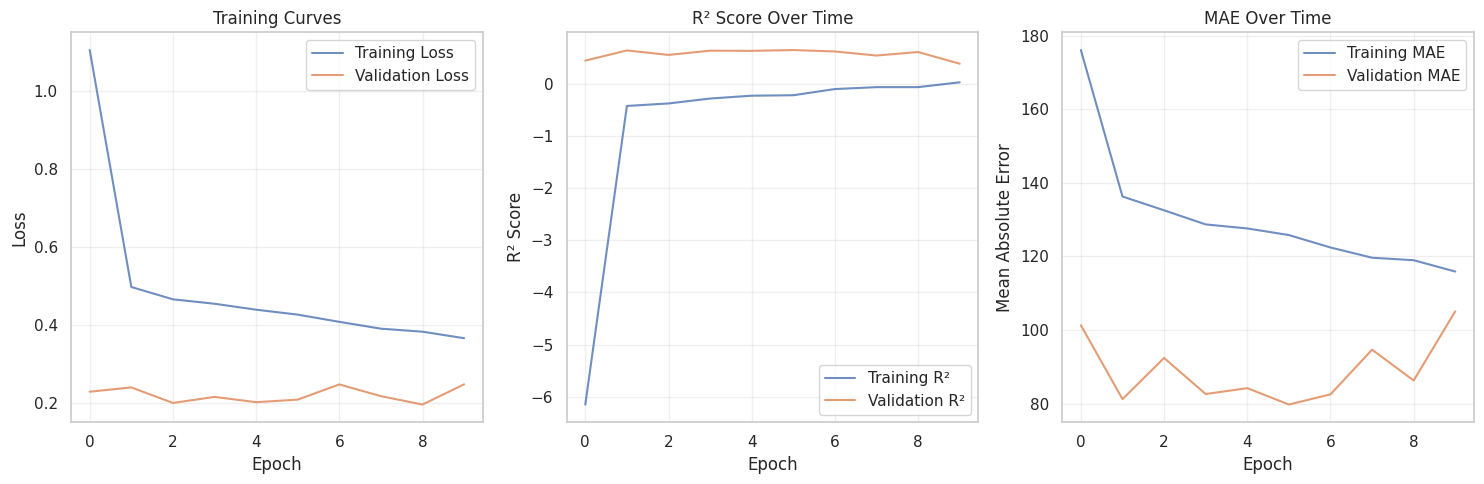

\n============================================================
FINAL TRAINING RESULTS
Training Time: 5197.69 seconds
Total Epochs: 10
Final Training Loss: 0.3665
Final Validation Loss: 0.2483
\nFinal Training Metrics:
  latency_mae: 115.9014
  latency_rmse: 172.0885
  latency_r2: 0.0340
\nFinal Validation Metrics:
  latency_mae: 105.0847
  latency_rmse: 141.7363
  latency_r2: 0.3911


In [22]:
# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(training_results['train_losses'], label='Training Loss', alpha=0.8)
plt.plot(training_results['val_losses'], label='Validation Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Curves')
plt.grid(True, alpha=0.3)

# Plot R² scores over time
train_r2_scores = [m.get('latency_r2', np.nan) for m in training_results['train_metrics']]
val_r2_scores = [m.get('latency_r2', np.nan) for m in training_results['val_metrics']]

plt.subplot(1, 3, 2)
plt.plot(train_r2_scores, label='Training R²', alpha=0.8)
plt.plot(val_r2_scores, label='Validation R²', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.legend()
plt.title('R² Score Over Time')
plt.grid(True, alpha=0.3)

# Plot MAE over time
train_mae_scores = [m.get('latency_mae', np.nan) for m in training_results['train_metrics']]
val_mae_scores = [m.get('latency_mae', np.nan) for m in training_results['val_metrics']]

plt.subplot(1, 3, 3)
plt.plot(train_mae_scores, label='Training MAE', alpha=0.8)
plt.plot(val_mae_scores, label='Validation MAE', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('MAE Over Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_metrics = training_results['train_metrics'][-1] if training_results['train_metrics'] else {}
final_val_metrics = training_results['val_metrics'][-1] if training_results['val_metrics'] else {}

print("\\n" + "="*60)
print("FINAL TRAINING RESULTS")
print("="*60)
print(f"Training Time: {training_results['training_time']:.2f} seconds")
print(f"Total Epochs: {len(training_results['train_losses'])}")
print(f"Final Training Loss: {training_results['train_losses'][-1]:.4f}")
print(f"Final Validation Loss: {training_results['val_losses'][-1]:.4f}")

if final_train_metrics:
    print(f"\\nFinal Training Metrics:")
    for metric, value in final_train_metrics.items():
        print(f"  {metric}: {value:.4f}")

if final_val_metrics:
    print(f"\\nFinal Validation Metrics:")
    for metric, value in final_val_metrics.items():
        print(f"  {metric}: {value:.4f}")


## Model Evaluation and Prediction Analysis


Evaluating model: 100%|██████████| 63/63 [01:23<00:00,  1.33s/it]


\n============================================================
COMPREHENSIVE EVALUATION RESULTS
Latency Prediction:
  MAE: 104.8435 ms
  RMSE: 142.2183 ms
  R²: 0.4124
  MAPE: 40.21%


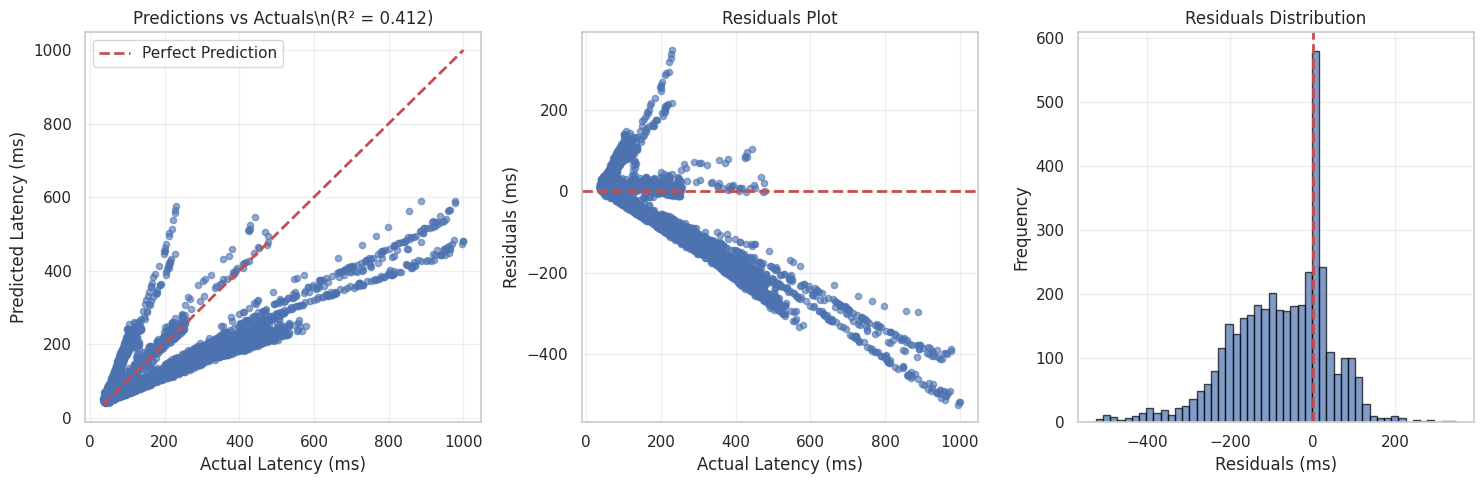

\n----------------------------------------
ERROR ANALYSIS BY PREDICTION RANGE
----------------------------------------
0-50ms    : MAE= 11.46, R²=-15.676, Count= 208
50-100ms  : MAE= 34.18, R²=-8.898, Count= 762
100-200ms : MAE= 50.12, R²=-3.763, Count=1021
200-500ms : MAE=140.84, R²=-2.325, Count=1704
500+ms    : MAE=327.14, R²=-4.026, Count= 305


In [23]:
# Detailed evaluation on validation set
model.eval()
all_predictions = []
all_actuals = []
all_energies_pred = []
all_energies_actual = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating model"):
        batch = batch.to(trainer.device)
        outputs = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        
        mask = batch.mask
        if mask.sum() > 0:
            # Latency predictions
            latency_pred = outputs['latency'][mask].cpu().numpy()
            latency_actual = batch.latency_target[mask].cpu().numpy()
            
            # Transform back if using log latency
            if config.use_log_latency:
                latency_pred = np.expm1(latency_pred)
                latency_actual = np.expm1(latency_actual)
            
            all_predictions.extend(latency_pred)
            all_actuals.extend(latency_actual)
            
            # Energy predictions (if multi-task)
            if config.multi_task and 'energy' in outputs:
                energy_pred = outputs['energy'][mask].cpu().numpy()
                energy_actual = batch.energy_target[mask].cpu().numpy()
                all_energies_pred.extend(energy_pred)
                all_energies_actual.extend(energy_actual)

# Convert to numpy arrays
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Calculate comprehensive metrics
mae = mean_absolute_error(all_actuals, all_predictions)
rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
r2 = r2_score(all_actuals, all_predictions)
mape = np.mean(np.abs((all_actuals - all_predictions) / all_actuals)) * 100

print("\\n" + "="*60)
print("COMPREHENSIVE EVALUATION RESULTS")
print("="*60)
print(f"Latency Prediction:")
print(f"  MAE: {mae:.4f} ms")
print(f"  RMSE: {rmse:.4f} ms")
print(f"  R²: {r2:.4f}")
print(f"  MAPE: {mape:.2f}%")

if all_energies_pred:
    energy_mae = mean_absolute_error(all_energies_actual, all_energies_pred)
    energy_r2 = r2_score(all_energies_actual, all_energies_pred)
    print(f"\\nEnergy Prediction:")
    print(f"  MAE: {energy_mae:.4f}")
    print(f"  R²: {energy_r2:.4f}")

# Visualization of predictions vs actuals
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(all_actuals, all_predictions, alpha=0.6, s=20)
plt.plot([all_actuals.min(), all_actuals.max()], 
         [all_actuals.min(), all_actuals.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Latency (ms)')
plt.ylabel('Predicted Latency (ms)')
plt.title(f'Predictions vs Actuals\\n(R² = {r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
residuals = all_predictions - all_actuals
plt.scatter(all_actuals, residuals, alpha=0.6, s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Actual Latency (ms)')
plt.ylabel('Residuals (ms)')
plt.title('Residuals Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals (ms)')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error analysis by prediction range
print("\\n" + "-"*40)
print("ERROR ANALYSIS BY PREDICTION RANGE")
print("-"*40)

# Define ranges
ranges = [(0, 50), (50, 100), (100, 200), (200, 500), (500, float('inf'))]
for low, high in ranges:
    mask = (all_actuals >= low) & (all_actuals < high)
    if mask.sum() > 0:
        range_mae = mean_absolute_error(all_actuals[mask], all_predictions[mask])
        range_r2 = r2_score(all_actuals[mask], all_predictions[mask])
        count = mask.sum()
        range_name = f"{low}-{high}ms" if high != float('inf') else f"{low}+ms"
        print(f"{range_name:10s}: MAE={range_mae:6.2f}, R²={range_r2:6.3f}, Count={count:4d}")

In [24]:
# Restore the best weights (from Epoch 4 with Val R² = 0.8334)
print("Restoring best weights...")
model.load_state_dict(trainer.early_stopping.best_weights)

# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'best_val_loss': trainer.early_stopping.best_loss,
    'train_losses': trainer.train_losses,
    'val_losses': trainer.val_losses,
    'train_metrics': trainer.train_metrics,
    'val_metrics': trainer.val_metrics
}, 'best_gnn_model.pt')

print("✅ Best model saved!")

Restoring best weights...
✅ Best model saved!
